## Anti Money Laundering (AML) 
Money laundering is the process used to disguise the source of money or assets derived from criminal activity. Money laundering involves approximately  590 USD  billion to  1.5 trillion USD per year worldwide. In 2018, 46.7 billion USD was laundered through Canada with 7.4 billion USD accounted in British Columbia. Canadian real state is a prime target for money laundering. For banks, it is important to comply the legislation from FINTRAC and OSFI.

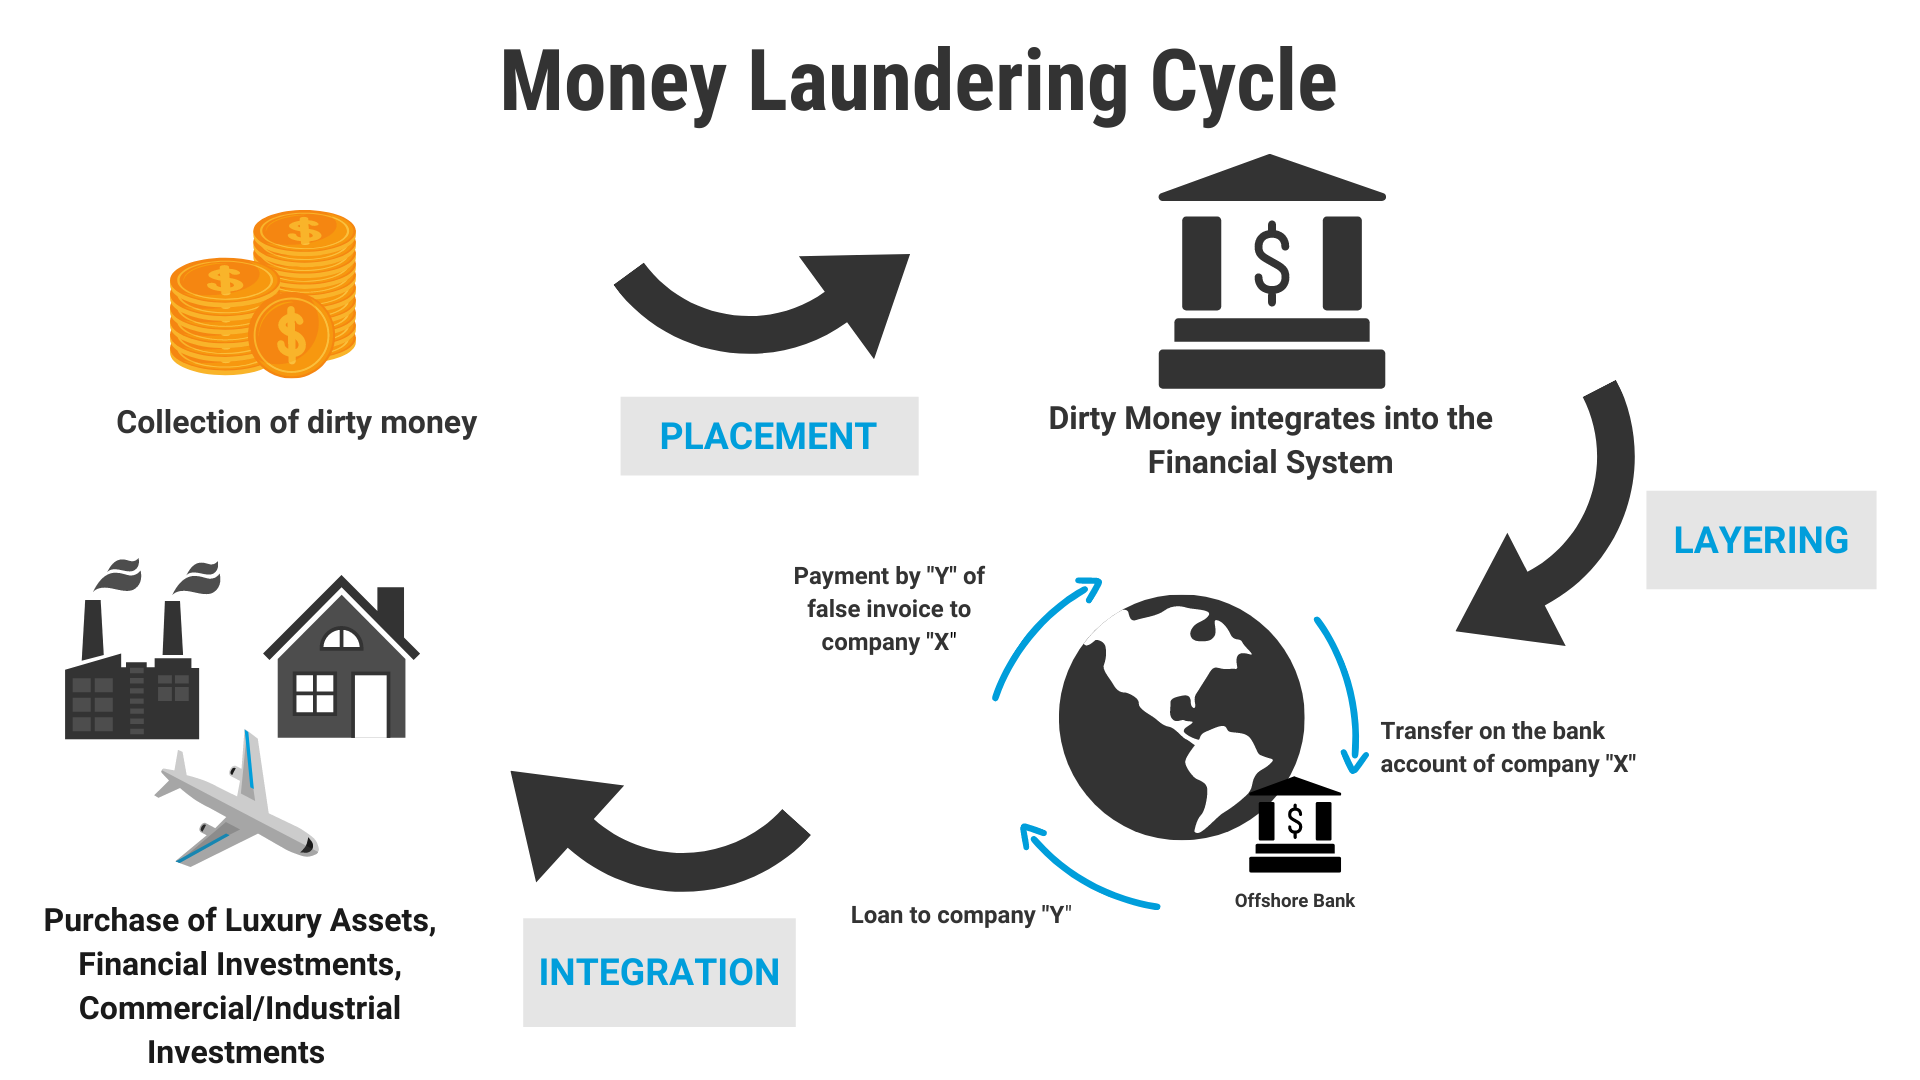

In [26]:
from IPython.display import Image
from IPython.core.display import HTML
Image(filename = "aml.png", width=800, height=800)

For the sake of the task, it is important to reduce the false positive alarms while having very low tolerance to false negatives. False negatives, are critical because they may be problematic for the bank in terms of legislation and affect the reputation of the bank. It is important to analyze the context of the transactions/users relationships to improve effectiveness of the alarms.

## Description of the dataset

The Elliptic Dataset (Kaggle: https://www.kaggle.com/datasets/ellipticco/elliptic-data-set) is a graph network of Bitcoin transactions with handcrafted features. All features are constructed using only publicly available information. The Elliptic DataSet maps Bitcoin transactions to real entities in two categories:

    - Licit: exchanges, wallet providers, miners, licit services, etc.
    - Ilicit: scams, malware, terrorist, organization, ransomware, Ponzi shcemes, etc.

The task on the dataset is to classify the illicit and licit nodes in the graph. A given transaction is licit if the entity that generated it was licit.

Credit: M. Weber, G. Domeniconi, J. Chen, D. K. I. Weidele, C. Bellei, T. Robinson, C. E. Leiserson, "Anti-Money Laundering in Bitcoin: Experimenting with Graph Convolutional Networks for Financial Forensics", KDD ’19 Workshop on Anomaly Detection in Finance, August 2019, Anchorage, AK, USA.

### Nodes and edges: 
This anonymized data set is a transaction graph collected from the Bitcoin blockchain. There are 203,769 node transactions and 234,355 directed edge payments flows out of which 2% are ilicit (class 1), 21% are licit (class 2). 

### Features:  
Each node has 166 features associated: the first 94 features represent local information including timestep, number of inputs/outputs, transaction fee, output volume and aggregated figures such as average BTC received (spent) by the inputs/outputs and average number of incoming (outgoing) transactions associated with the inputs/outputs. The remaining 72 features represent aggregated features that are obtained using transaction information one-hop backward/forward from the center node - giving the maximum, minimum, standard deviation and correlation coefficients of the neighbor transactions for the same information data (number of inputs/outputs, transaction fee, etc.).

### Temporal information: 
A time step is associated with each node, representing an estimated of the time when the transaction is confirmed. There are 49 distinct timesteps evenly spaced with an interval of 2 weeks. 

In [27]:
from __future__ import print_function, division
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
import networkx as nx
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.offline as py 
import plotly.graph_objs as go 
py.init_notebook_mode(connected=True)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(15)

## Credit 
Slightly based on Kaggle notebook: https://www.kaggle.com/code/dhruvrnaik/illicit-transaction-detection/notebook

In [28]:
datadir_path = "/home/karim/Projects/Crypto4GraphAI/AML_on_Bitcoin_Elliptic_Dataset/data/elliptic_bitcoin_dataset/"

In [29]:
edges = pd.read_csv(datadir_path + "/elliptic_txs_edgelist.csv")
features = pd.read_csv(datadir_path + "/elliptic_txs_features.csv", header=None) 
classes = pd.read_csv(datadir_path + "/elliptic_txs_classes.csv")

In [30]:
len(edges), len(features), len(classes)

(234355, 203769, 203769)

In [31]:
display(edges.head(5), features.head(5), classes.head(5))

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,-0.511871,-0.400422,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117


,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [32]:
tx_features = ["Local_feature_"+str(i) for i in range(2, 95)]
agg_features = ["Aggregate_feature_"+str(i) for i in range(1, 73)]

features.columns = ["txId", "time_step"] + tx_features + agg_features
features = pd.merge(features, classes, left_on="txId", right_on="txId", how='left')
features['class'] = features['class'].apply(lambda x: '0' if x == "unknown" else x)

In [33]:
features.groupby('class').size()

class
0    157205
1      4545
2     42019
dtype: int64

<BarContainer object of 3 artists>

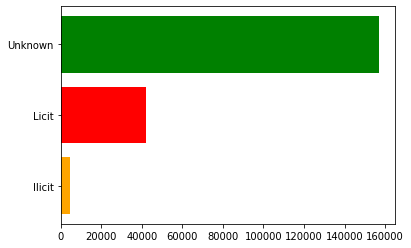

In [34]:
group_class = classes.groupby('class').count()
plt.barh(['Ilicit', 'Licit', 'Unknown'], group_class['txId'].values, color=['orange', 'r', 'g'] )

Text(0.5, 1.0, 'Number of transactions by Time step')

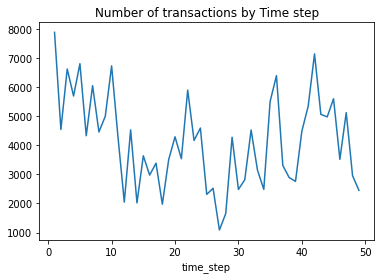

In [35]:
group_feature = features.groupby('time_step').count()
group_feature['txId'].plot()
plt.title('Number of transactions by Time step')

In [36]:
group_class_feature = features.groupby(['time_step', 'class']).count()
#plt.barh(['Unknown', 'Ilicit', 'Licit'], group_class['txId'].values, color=['orange', 'r', 'g'] )
group_class_feature = group_class_feature['txId'].reset_index().rename(columns={'txId': 'count'})#unstack()
group_class_feature.head()

,time_step,class,count
0,1,0,5733
1,1,1,17
2,1,2,2130
3,2,0,3427
4,2,1,18


<AxesSubplot:xlabel='time_step', ylabel='count'>

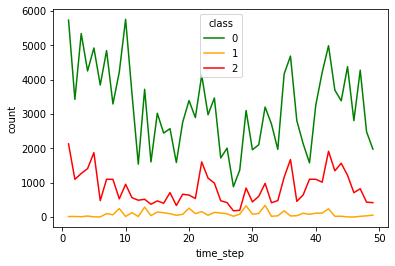

In [37]:
import seaborn as sns
sns.lineplot(x='time_step', y='count', hue='class', data = group_class_feature, palette=['g', 'orange', 'r'] )

In [38]:
features.tail()

,txId,time_step,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,...,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72,class
203764,173077460,49,-0.145771,-0.163752,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,-0.135803,...,-0.613614,0.241128,0.241406,0.018279,-0.08749,-0.131155,-0.097524,-0.120613,-0.119792,0
203765,158577750,49,-0.165920,-0.123607,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.156418,...,0.010822,1.461330,1.461369,-0.098889,-0.08749,-0.084674,-0.140597,-1.760926,-1.760984,0
203766,158375402,49,-0.172014,-0.078182,1.018602,0.028105,-0.043875,0.054722,-0.061584,-0.163626,...,1.985050,1.461330,1.461369,0.018279,-0.08749,-0.131155,-0.097524,-0.120613,-0.119792,1
203767,158654197,49,-0.172842,-0.176622,1.018602,-0.121970,-0.043875,-0.113002,-0.061584,-0.163501,...,-0.411776,1.461330,1.461369,-0.098889,-0.08749,-0.084674,-0.140597,1.519700,1.521399,0
203768,157597225,49,-0.012037,-0.132276,0.463609,-0.121970,-0.043875,-0.113002,-0.061584,0.001027,...,-0.613614,0.241128,0.241406,-0.098889,-0.08749,-0.084674,-0.140597,1.519700,1.521399,0


In [39]:
features_sampled = features.loc[features['time_step'] <= 42]
features_sampled.tail()

,txId,time_step,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,...,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72,class
174080,73262069,42,-0.166681,0.016948,1.018602,-0.12197,-0.043875,-0.113002,-0.061584,-0.157192,...,-0.600999,1.461330,1.461369,0.018279,-0.08749,-0.131155,-0.097524,-0.120613,-0.119792,2
174081,71822792,42,-0.167077,-0.193365,-0.091383,-0.12197,-0.043875,-0.113002,-0.061584,-0.157603,...,1.638141,-0.979074,-0.978556,0.018279,-0.08749,-0.131155,-0.097524,-0.120613,-0.119792,2
174082,70826998,42,-0.172615,-0.165896,1.018602,-0.12197,-0.043875,-0.113002,-0.061584,-0.163268,...,-0.008100,-0.979074,-0.978556,-0.098889,-0.08749,-0.084674,-0.140597,1.519700,1.521399,0
174083,65835365,42,-0.172896,0.016948,1.018602,-0.12197,-0.043875,-0.113002,-0.061584,-0.163552,...,0.780330,1.461330,1.461369,0.018279,-0.08749,-0.131155,-0.097524,-0.120613,-0.119792,0
174084,73264067,42,-0.172950,0.016948,1.018602,-0.12197,-0.043875,-0.113002,-0.061584,-0.163607,...,3.971893,-0.979074,-0.978556,-0.098889,-0.08749,-0.084674,-0.140597,-1.760926,-1.760984,2


In [40]:
count_by_class = features[["time_step",'class']].groupby(['time_step','class']).size().to_frame().reset_index()
illicit_count = count_by_class[count_by_class['class'] == '1']
licit_count = count_by_class[count_by_class['class'] == '2']
unknown_count = count_by_class[count_by_class['class'] == "0"]

In [41]:
x_list = list(range(1,50))
fig = go.Figure(data = [
    go.Bar(name="Unknown",x=x_list,y=unknown_count[0],marker = dict(color = 'rgba(120, 100, 180, 0.6)',
        line = dict(
            color = 'rgba(120, 100, 180, 1.0)',width=1))),
    go.Bar(name="Licit",x=x_list,y=licit_count[0],marker = dict(color = 'rgba(246, 78, 139, 0.6)',
        line = dict(
            color = 'rgba(246, 78, 139, 1.0)',width=1))),
    go.Bar(name="Illicit",x=x_list,y=illicit_count[0],marker = dict(color = 'rgba(58, 190, 120, 0.6)',
        line = dict(
            color = 'rgba(58, 190, 120, 1.0)',width=1)))

])

fig.update_layout(barmode='stack')
py.iplot(fig)

## Illicit Transactions

In [42]:
bad_ids = features[(features['time_step'] == 32) & ((features['class'] == '1'))]['txId']
short_edges = edges[edges['txId1'].isin(bad_ids)]
graph = nx.from_pandas_edgelist(short_edges, source = 'txId1', target = 'txId2', 
                                 create_using = nx.DiGraph())
pos = nx.spring_layout(graph)

edge_x = []
edge_y = []

for edge in graph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='blue'),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
node_text=[]
for node in graph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        color=[],
        size=10,
        colorbar=dict(
            thickness=15,
            title='Transaction Type',
            xanchor='left',
            titleside='right',
            tickmode='array',
            tickvals=[0,1,2],
            ticktext=['Unknown','Illicit','Licit']
        ),
        line_width=2))
node_trace.text=node_text
node_trace.marker.color = pd.to_numeric(features[features['txId'].isin(list(graph.nodes()))]['class'])

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title="Illicit Transactions",
                titlefont_size=16,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    showarrow=True,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.show()

## Licit Transactions

In [43]:
good_ids = features[(features['time_step'] == 32) & ((features['class'] == '2'))]['txId']
short_edges = edges[edges['txId1'].isin(good_ids)]
graph = nx.from_pandas_edgelist(short_edges, source = 'txId1', target = 'txId2', 
                                 create_using = nx.DiGraph())
pos = nx.spring_layout(graph)

edge_x = []
edge_y = []

for edge in graph.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='blue'),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
node_text=[]
for node in graph.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_text.append(node)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        color=[],
        size=10,
        colorbar=dict(
            thickness=15,
            title='Transaction Type',
            xanchor='left',
            titleside='right',
            tickmode='array',
            tickvals=[0,1,2],
            ticktext=['Unknown','Illicit','Licit']
        ),
        line_width=2))
node_trace.text=node_text
node_trace.marker.color = pd.to_numeric(features[features['txId'].isin(graph.nodes())]['class'])

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title="Licit Transactions",
                titlefont_size=16,
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    showarrow=True,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.show()

In [44]:
data = features_sampled[(features_sampled['class']=='1') | (features_sampled['class']=='2')]

In [45]:
data.head()

,txId,time_step,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,...,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72,class
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2
9,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,...,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792,2
10,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
11,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,...,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
16,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,...,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984,2


In [46]:
X = data[tx_features+agg_features]
y = data['class']
y = y.apply(lambda x: 0 if x == '2' else 1 )
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15, shuffle=False)

In [47]:
X_train.head()

,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,Local_feature_10,Local_feature_11,...,Aggregate_feature_63,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72
3,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,-0.115831,0.043598,...,-0.577099,-0.613614,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792
9,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,-0.144554,0.020069,...,-0.577099,-0.613614,0.241128,0.241406,0.604120,0.008632,-0.131155,0.333211,-0.120613,-0.119792
10,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,-0.144108,-0.049707,...,-0.577099,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
11,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,-0.147643,-0.049707,...,-0.539735,-0.582077,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
16,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,-0.169115,-0.047227,...,-0.577099,-0.600999,0.241128,0.241406,0.018279,-0.068266,-0.084674,-0.054450,-1.760926,-1.760984


In [48]:
clf = RandomForestClassifier(n_estimators=50, max_depth=100,random_state=15).fit(X_train,y_train)
preds = clf.predict(X_test)
prec, rec, f1, num = precision_recall_fscore_support(y_test,preds, average=None)

print("Random Forest Classifier")
print("Precision:%.3f \nRecall:%.3f \nF1 Score:%.3f"%(prec[1],rec[1],f1[1]))

micro_f1 = f1_score(y_test,preds,average='micro')
print("Micro-Average F1 Score:",micro_f1)

Random Forest Classifier
Precision:0.989 
Recall:0.874 
F1 Score:0.928
Micro-Average F1 Score: 0.9857907054496824


## Using upto 34 time step for training and 35 to 43 for testing 

In [45]:
data_train = data.loc[features['time_step'] <= 34]
X_train = data_train[tx_features+agg_features]

y_train = data_train['class']
y_train = y_train.apply(lambda x: 0 if x == '2' else 1 )

In [50]:
data_train.tail()

,txId,time_step,Local_feature_2,Local_feature_3,Local_feature_4,Local_feature_5,Local_feature_6,Local_feature_7,Local_feature_8,Local_feature_9,...,Aggregate_feature_64,Aggregate_feature_65,Aggregate_feature_66,Aggregate_feature_67,Aggregate_feature_68,Aggregate_feature_69,Aggregate_feature_70,Aggregate_feature_71,Aggregate_feature_72,class
136241,119222131,34,-0.172968,-0.071395,0.463609,-0.12197,-0.043875,-0.113002,-0.061584,-0.163627,...,1.266002,1.461330,1.461369,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,2
136243,77410785,34,-0.172924,-0.107411,1.018602,-0.12197,-0.063725,-0.113002,-0.061584,-0.163583,...,0.534340,0.241128,0.241406,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,1
136249,288397726,34,-0.172897,-0.070152,0.463609,-0.12197,-0.043875,-0.113002,-0.061584,-0.163555,...,-0.146863,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
136250,227494727,34,-0.155367,-0.081852,0.463609,-0.12197,-0.043875,-0.113002,-0.061584,-0.145619,...,-0.613614,0.241128,0.241406,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,2
136258,238473788,34,-0.172981,-0.070152,0.463609,-0.12197,-0.043875,-0.113002,-0.061584,-0.163641,...,0.635259,0.241128,0.241406,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,2


In [46]:
data_test = data.loc[features['time_step'] >= 35]
X_test = data_test[tx_features+agg_features]

y_test = data_test['class']
y_test = y_test.apply(lambda x: 0 if x == '2' else 1 )

In [47]:
X_train.shape, X_test.shape

((29894, 165), (9983, 165))

In [48]:
clf = RandomForestClassifier(n_estimators=50, max_depth=100, random_state=15).fit(X_train, y_train)
preds = clf.predict(X_test)
prec, rec, f1, num = precision_recall_fscore_support(y_test, preds, average=None)

print("Random Forest Classifier")
print("Precision:%.3f \nRecall:%.3f \nF1 Score:%.3f"%(prec[1], rec[1], f1[1]))

micro_f1 = f1_score(y_test, preds, average='micro')
print("Micro-Average F1 Score:", micro_f1)

Random Forest Classifier
Precision:0.972 
Recall:0.847 
F1 Score:0.905
Micro-Average F1 Score: 0.9837724131022738
